# Figure 3: `single_site`

This notebook rebuilds the figure step by step from its script, `figures/main/fig3_single_site.py`. Every code cell below is a verbatim slice of that file, in the order the file defines it: first the imports and configuration, then each helper function with a short explanation, then the body of `main()` laid out as the assembly of the panels, and finally the rendered figure with its caption. Run the cells top to bottom; in the reference environment the PNG written at the end is identical to the submitted manuscript file (see docs/REPRODUCIBILITY.md).

Figure 3 is the single-site deep dive behind the paper's first claim: an encoding model that predicts natural-image responses very well can still fail to control the site precisely. The default site is Monkey R, aIT unit 9 (labelled "channel 2" in the manuscript) with ResNet50. Panel a embeds the natural calibration images, drawn as thumbnails colored and sized by recorded firing rate, in the readout-aligned basis, and beside them the ten accentuation sweeps projected into the same space. Panel b shows four of those sweeps as image strips. Panel c is the encoding check: predicted versus measured rate for held-out natural images, first from the calibration session (phase 1) and then for the same held-out images re-presented in the control session (phase 2). Panel d is the control test: predicted versus measured on the accentuated stimuli, with per-seed sweeps connected.

The embedding for panel a comes from a cache (`preprocessed_data/fig3_data_<monkey>_unit<unit>_<model>.pkl`, built by `scripts/preprocessing/build_fig3_embedding.py`, which needs torch). Everything else is computed here from the `pnc.preproc.loader` caches: the brain cache (trial-level responses for both sessions), the encoding cache (model predictions for calibration images) and the predictions cache (model predictions for accentuated stimuli). Panel b reads the raw accentuated images. This script has no sibling helper module; it imports only from `pnc`.

## What the script says about itself

Figure 3 - a highly predictive encoding model of natural images can fail to precisely control neural firing (single-site ResNet50 deep dive).

Site: Monkey R, aIT unit 9 (manuscript label "channel 2"), ResNet50.

- **(a)** Embedding of encoding + accentuated stimuli in the readout-aligned basis: image-icon cloud (left) + accentuation trajectories over the natural-image distribution (right), sharing the green encoding axis.
- **(b)** Accentuated image sweeps - 4 seeds x 7 levels, suppress -> seed -> drive.
- **(c)** Encoding generalization: phase 1 (held-out natural, encoding phase) and phase 2 (held-out calibration images re-presented in the control session; P2SET selects the re-test set, canonical = 'heldout').
- **(d)** Parametric neural control: predicted vs measured on accentuated stims.

Data:

* Panels c/d scatter stats come from pnc.preproc.loader:

c-phase1 -> L.encoding_cloud('red',9,'resnet50','test')

c-phase2 -> control-session responses to the re-presented calibration images that pass _p2_keep (held-out validation items), predicted by the encoding cache; built in this script, not via L.anchor_cloud (which uses every anchor) d        -> L.control_cloud('red',9,'resnet50') Pearson r + OLS slope are fit in the loader's z-space; plotting is in spk/s* via the per-unit mu/sigma from the brain cache.

* nc_r (displayed alongside r) is the NSD noise ceiling of the panel's own

stimulus group (the max achievable r given reliability, NOT r/ceiling).

* Panel a embedding is read from the cache

preprocessed_data/fig3_data_<monkey>_unit<unit>_<model>.pkl, built from raw shared data by scripts/preprocessing/build_fig3_embedding.py (needs torch).

* Panel b mosaic uses raw accentuation + seed images; achieved scores are

clamped with L.firing_floor('red',9).

Usage: python -m figures.main.fig3_single_site --out DIR                 # manuscript render python -m figures.main.fig3_single_site --out DIR --ingredients   # bare per-element export python -m figures.main.fig3_single_site --out DIR --monkey paul --unit 8 --channel-label 3

## 1. Environment

A few lines that are not in the script: they make the notebook render exactly like the command-line harness does (single-threaded BLAS, the Agg backend with matplotlib defaults, the repository on the import path) and check that the preprocessed data are present.

In [1]:
import os, sys
from pathlib import Path

# Keep BLAS single-threaded: multithreaded OpenMP together with torch can kill the kernel on macOS.
for _v in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS'):
    os.environ.setdefault(_v, '1')
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

# Render with the Agg backend and matplotlib's defaults, exactly like the figure scripts;
# Jupyter's inline backend would otherwise change dpi and bounding boxes.
os.environ['MPLBACKEND'] = 'Agg'
import matplotlib; matplotlib.use('Agg'); matplotlib.rcdefaults()

# Work from the repository root whether the notebook is opened there or in notebooks/figures/.
REPO = Path.cwd() if (Path.cwd() / 'pnc').exists() else Path.cwd().parents[1]
sys.path.insert(0, str(REPO))
from pnc import paths

# The figures read the preprocessed caches only; this raises a clear message if they are missing.
paths.require(paths.preprocessed_data() / 'brain_red.pkl')   # python data/download_data.py --tier preprocessed
OUT_DIR = paths.output_dir() / 'figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)

## 2. Imports, style and configuration

The script starts by importing the study configuration and figure style from `pnc` (colours, model names, the publication rcParams) and the cache loader, then fixes the constants that the panels share: which sites and models are shown, layout sizes, colour choices, and where the inputs live. `apply_figure_style()` is what makes every figure in the paper look the same.

`MONKEY`, `UNIT`, `MODEL` and `CHANNEL_LABEL` select the site; the command-line flags `--monkey`, `--unit`, `--model` and `--channel-label` re-bind them through `_configure`. `P2SET` chooses the phase-2 stimulus set: `heldout` (the canonical choice, only held-out validation images), `allcal` (every re-presented calibration image, including model-training images) or the legacy `nsd`. `BARE` (the `--ingredients` flag) exports each panel as a separate bare image instead of the composite. For panel b, `C_SEEDS` picks the four seeds, `SUPPRESS_IDX` and `DRIVE_IDX` the three levels on each side of the seed, and `C_THUMB` and `BORDER` the pixel sizes. `AXIS_TEAL` is the encoding-axis color shared with Figure 2.

In [2]:
from __future__ import annotations

import os

import pickle

from collections import defaultdict

import numpy as np

from PIL import Image, ImageFile, ImageEnhance

ImageFile.LOAD_TRUNCATED_IMAGES = True

import matplotlib

matplotlib.use('Agg')

import matplotlib.pyplot as plt

import matplotlib.colors as mcolors

from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

from matplotlib.patches import Polygon

from matplotlib.offsetbox import OffsetImage, AnnotationBbox

from scipy import stats

from pnc import paths

from pnc.manifest import MAIN_FIGURES

from pnc.utils import (
    apply_figure_style, FONT_FAMILY, DPI,
    MODEL_COLORS, MODEL_SHORT_NAMES, DATA_ROOT, STIMULI_PATH, MONKEY_DIRS,
    ACCENT_DATE_PREFIXES, parse_stimulus_name, save_fig,
)

from pnc.preproc import loader as L

apply_figure_style()

PREPROC_DATA = str(paths.preprocessed_data())

# ── site / model ───────────────────────────────────────────────────────
# Defaults = the manuscript hero (red aIT unit 9, ResNet50 = "channel 2"). main() can
# render alternative example sites via its keyword arguments (--monkey / --unit / --model /
# --channel-label / --p2set), which re-bind these module globals for the run.
MONKEY = 'red'

UNIT = 9          # data source: aIT unit 9

MODEL = 'resnet50'

CHANNEL_LABEL = '2'  # manuscript-facing label

MODEL_COLOR = MODEL_COLORS[MODEL]

_REGION_BY_MONKEY = {'red': 'aIT', 'paul': 'cIT', 'venus': 'V3/V4', 'leap': 'STS', 'three0': 'STS'}

REGION = _REGION_BY_MONKEY.get(MONKEY, '?')

# Phase-2 (cross-phase re-test) stimulus set; canonical = 'heldout'.
#   heldout  re-presented calibration images that are held-out validation items
#   allcal   every re-presented calibration image (includes model-training images)
#   nsd      legacy: NSD 'shared####' filenames only (mixes train/validation and
#            drops the re-presented segmented-object / fLoc images)
P2SET = 'heldout'

## 3. The building blocks

Each function below is one component of the figure: loading and shaping a cache, computing a statistic, or drawing one panel into an axes it is handed. They are defined here exactly as in the script and used by the assembly in the last section; read them in order, the assembly calls them in roughly the same order.

The helpers fall into three groups. The first estimates noise ceilings (`_anchor_trial_noise`, `_nsd_ceiling`, `compute_group_ceilings`). The second pairs model predictions with measured responses and keeps the stimulus names so per-stimulus error bars can be attached (`_encoding_named`, `_shared_named`, `_control_named`, the SEM lookups, and `compute_scatter_stats`). The third draws: image loaders for panel b, the panel-a renderers, and the shared `_scatter_panel` used by c and d.

### `_p2_keep(name, kind, heldout)`

Membership test for the phase-2 cross-phase re-test set (see P2SET).

Membership test for the phase-2 set. Under `heldout` a stimulus counts only if it is a calibration-kind image that appears in the site's held-out validation list; `allcal` keeps every calibration image and `nsd` keeps NSD filenames only.

In [3]:
def _p2_keep(name, kind, heldout):
    """Membership test for the phase-2 cross-phase re-test set (see P2SET)."""
    if P2SET == 'nsd':
        return kind == 'calibration' and 'shared' in str(name).lower()
    if kind != 'calibration':
        return False
    if P2SET == 'allcal':
        return True
    return heldout is None or name in heldout

More configuration used by the functions below.

In [4]:
# ── modes ──────────────────────────────────────────────────────────────
BARE = False

# ── paths ──────────────────────────────────────────────────────────────
CACHE_PATH = os.path.join(PREPROC_DATA, f'fig3_data_{MONKEY}_unit{UNIT}_{MODEL}.pkl')

# ── panel-b mosaic config ───────────────────────────────────────────────
C_SEEDS = [3, 4, 7, 9]          # top row = seed 3 (shared0241, the cat)

C_THUMB = 110

C_PAD = 3

SUPPRESS_IDX = [0, 1, 3]

DRIVE_IDX = [6, 7, 9]

SEED_COL = len(SUPPRESS_IDX)          # center (seed) column index = 3

BORDER = 5                            # colored frame thickness

# ── accent colours (green encoding axis) ───────────────────────────────
AXIS_TEAL = '#00C39A'

# ── typography ─────────────────────────────────────────────────────────
SZ_PANEL = 25

SZ_TITLE = 13.5

SZ_SUBTITLE = 12

SZ_AXIS = 16

SZ_TICK = 13.5

SZ_STAT = 10.5

SZ_ANNOT = 14.5

### `_anchor_trial_noise(zc, tsn, days, anchor_set, min_groups=5)`

══════════════════════════════════════════════════════════════════════ NC_R - noise-ceiling definition ══════════════════════════════════════════════════════════════════════ The "nc r" printed in each scatter's stat box is the NSD noise CEILING of that panel's own stimulus group (the maximum Pearson r attainable given the channel's trial reliability on that stim set) - the same quantity earlier drafts displayed. It is NOT r divided by the ceiling. # It is computed with the canonical NSD estimator (pnc/preproc/ceilings.py): trial noise = pooled SAME-DAY repeat variance of the encoding anchors present in the control session (pure trial noise); signal var  = Var_i(mean_j z_{i,j}) - trial_noise * mean_i(1/n_i)  over the group's stimuli with >=2 repeats; ncsnr       = sqrt(signal var) / sqrt(trial noise); nc_r        = sqrt( ncsnr^2 / (ncsnr^2 + mean_i(1/n_i)) ). # For the CONTROL (accentuated) group this is exactly the canonical stored value L.ceilings_df('red') nc_r for (unit 9, resnet50); the inline estimator below reproduces it bit-for-bit and is also used for the phase-2 (shared) group. Both use control-session trial-level data from the brain cache. # PHASE 1 (held-out encoding-phase stimuli): the brain cache retains encoding-session single trials (calibration.trial_stim / trial_z, added in run_preproc.build_brain_main), so the phase-1 NSD ceiling + per-stim SEM are computed the same way as phase-2 / control. All three panels are fully self-contained.

Pooled same-day repeat variance of the calibration images presented in the control session (the anchors). This is the pure trial-noise term for the control-session ceilings; it returns NaN unless at least `min_groups` stimulus-by-day groups have two or more repeats.

In [5]:
# ══════════════════════════════════════════════════════════════════════
# NC_R - noise-ceiling definition
# ══════════════════════════════════════════════════════════════════════
# The "nc r" printed in each scatter's stat box is the NSD noise
# CEILING of that panel's own stimulus group (the maximum Pearson r
# attainable given the channel's trial reliability on that stim set) - the
# same quantity earlier drafts displayed. It is NOT r divided by the ceiling.
#
# It is computed with the canonical NSD estimator (pnc/preproc/ceilings.py):
#   trial noise = pooled SAME-DAY repeat variance of the encoding anchors
#                 present in the control session (pure trial noise);
#   signal var  = Var_i(mean_j z_{i,j}) - trial_noise * mean_i(1/n_i)  over
#                 the group's stimuli with >=2 repeats;
#   ncsnr       = sqrt(signal var) / sqrt(trial noise);
#   nc_r        = sqrt( ncsnr^2 / (ncsnr^2 + mean_i(1/n_i)) ).
#
# For the CONTROL (accentuated) group this is exactly the canonical stored
# value L.ceilings_df('red') nc_r for (unit 9, resnet50); the inline estimator
# below reproduces it bit-for-bit and is also used for the phase-2 (shared)
# group. Both use control-session trial-level data from the brain cache.
#
# PHASE 1 (held-out encoding-phase stimuli): the brain cache retains
# encoding-session single trials (calibration.trial_stim / trial_z, added in
# run_preproc.build_brain_main), so the phase-1 NSD ceiling + per-stim SEM are
# computed the same way as phase-2 / control. All three panels are fully
# self-contained.


def _anchor_trial_noise(zc, tsn, days, anchor_set, min_groups=5):
    grp = defaultdict(list)
    for i, s in enumerate(tsn):
        if s in anchor_set and np.isfinite(zc[i]):
            grp[(s, days[i])].append(zc[i])
    wd = [np.var(v, ddof=1) for v in grp.values() if len(v) >= 2]
    return float(np.mean(wd)) if len(wd) >= min_groups else np.nan

### `_nsd_ceiling(zc, tsn, stimset, noisevar, min_stim=8)`

The NSD noise-ceiling estimator. Signal variance is the variance of per-stimulus mean responses minus the trial noise scaled by the mean of one over the repeat count; the ceiling is then the correlation a perfect model could reach given that signal-to-noise ratio. It needs at least `min_stim` stimuli with two or more repeats and a positive noise estimate, otherwise NaN.

In [6]:
def _nsd_ceiling(zc, tsn, stimset, noisevar, min_stim=8):
    by = defaultdict(list)
    for i, s in enumerate(tsn):
        if s in stimset and np.isfinite(zc[i]):
            by[s].append(zc[i])
    means, reps = [], []
    for v in by.values():
        if len(v) >= 2:
            means.append(np.mean(v))
            reps.append(len(v))
    if len(means) < min_stim or not (np.isfinite(noisevar) and noisevar > 0):
        return np.nan
    datavar = np.var(means, ddof=1)
    inv_n = np.mean(1.0 / np.array(reps, float))
    if not (datavar > 0):
        return np.nan
    sig = max(datavar - noisevar * inv_n, 0.0)
    ncsnr = np.sqrt(sig) / np.sqrt(noisevar)
    return float(np.sqrt(ncsnr ** 2 / (ncsnr ** 2 + inv_n)))

### `compute_group_ceilings()`

Return dict of NSD noise ceilings per panel stim group, all from the control-session trial-level data (self-contained).

Computes one ceiling per panel group. Phase 1 uses the calibration-session single trials retained in the brain cache with their own pooled noise term; phase 2 and control use the control-session trials with the anchor-derived noise term. The control group is restricted to accentuated stimuli generated by this model for this unit. The value shown in each scatter's box is this ceiling itself, the maximum attainable r, not r divided by it.

In [7]:
def compute_group_ceilings():
    """Return dict of NSD noise ceilings per panel stim group, all from the
    control-session trial-level data (self-contained)."""
    b = L.load_brain(MONKEY)
    ui = list(b['units']).index(UNIT)
    c = b['control']
    tsn = np.asarray(c['trial_stim'])
    days = np.asarray(c['trial_day'])
    tz = np.asarray(c['trial_z'])[:, ui]
    tk = np.asarray(c['trial_kind'])

    enc_set = set(tsn[tk == 'calibration'].tolist())          # anchor set
    tnoise = _anchor_trial_noise(tz, tsn, days, enc_set)

    # cross-phase re-test set -- see P2SET (canonical: held-out validation only)
    _heldout = L._test_names(MONKEY)
    shared_set = set(n for n, k in zip(tsn, tk) if _p2_keep(n, k, _heldout))
    acc_set = set(n for n, k in zip(tsn, tk)
                  if k == 'accentuated'
                  and n.startswith(MODEL + '_RidgeCV')
                  and f'_unit_{UNIT}_' in n)

    # phase-1: from the encoding-session trials retained in the brain cache.
    cts, ctz = _calib_trials(UNIT)
    cnoise = _calib_noise(cts, ctz)
    keep = L._test_names(MONKEY)
    p1_set = keep if keep is not None else set(cts.tolist())
    return {
        'phase1': _nsd_ceiling(ctz, cts, p1_set, cnoise),
        'phase2': _nsd_ceiling(tz, tsn, shared_set, tnoise),
        'control': _nsd_ceiling(tz, tsn, acc_set, tnoise),
    }

### `load_embedding()`

══════════════════════════════════════════════════════════════════════ embedding cache (built by scripts/preprocessing/build_fig3_embedding.py) ══════════════════════════════════════════════════════════════════════

Reads the panel-a cache and prints its path; the hint in the error message tells you how to rebuild it.

In [8]:
# ══════════════════════════════════════════════════════════════════════
# embedding cache (built by scripts/preprocessing/build_fig3_embedding.py)
# ══════════════════════════════════════════════════════════════════════

def load_embedding():
    path = paths.require(CACHE_PATH,
                         hint=f'python scripts/preprocessing/build_fig3_embedding.py '
                              f'--monkey {MONKEY} --unit {UNIT} --model {MODEL}')
    with open(path, 'rb') as f:
        print(f'Loaded embedding cache: {path}')
        return pickle.load(f)

### `_fit(pred, true)`

══════════════════════════════════════════════════════════════════════ scatter stats from the loader ══════════════════════════════════════════════════════════════════════

Pearson r plus an ordinary least-squares slope and intercept, computed in z space. The slope is the quantity that separates good calibration from mere rank agreement.

In [9]:
# ══════════════════════════════════════════════════════════════════════
# scatter stats from the loader
# ══════════════════════════════════════════════════════════════════════

def _fit(pred, true):
    r = float(stats.pearsonr(pred, true)[0])
    reg = stats.linregress(pred, true)
    return r, float(reg.slope), float(reg.intercept)

### `_control_sem_z(unit)`

Per-stimulus SEM of the standardized response at `unit`, from the control-session trials (SEM = std/sqrt(n_reps)). Covers every accentuated + shared stimulus. Phase-1 encoding stimuli have no single-trial data in the cache, so they get no SEM.

Per-stimulus SEM of the standardized response from control-session trials (standard deviation over repeats divided by the square root of the repeat count). Covers accentuated and re-presented stimuli; phase-1 stimuli get their SEM from `_calib_sem_z` instead.

In [10]:
def _control_sem_z(unit):
    """Per-stimulus SEM of the standardized response at `unit`, from the control-session trials
    (SEM = std/sqrt(n_reps)). Covers every accentuated + shared stimulus. Phase-1 encoding
    stimuli have no single-trial data in the cache, so they get no SEM."""
    from collections import defaultdict
    b = L.load_brain(MONKEY); c = b['control']; ui = list(b['units']).index(unit)
    ts = np.asarray(c['trial_stim']); tz = np.asarray(c['trial_z'])[:, ui]
    d = defaultdict(list)
    for n, z in zip(ts, tz):
        if np.isfinite(z):
            d[n].append(float(z))
    out = {}
    for n, v in d.items():
        a = np.asarray(v)
        out[n] = float(a.std(ddof=1) / np.sqrt(len(a))) if len(a) > 1 else 0.0
    return out

### `_shared_named()`

Re-presented HELD-OUT calibration images, with names (to attach per-stim SEM).

Predicted and measured responses for the re-presented held-out calibration images, with names. Predictions come from the encoding cache, responses from the control session.

In [11]:
def _shared_named():
    """Re-presented HELD-OUT calibration images, with names (to attach per-stim SEM)."""
    b = L.load_brain(MONKEY); ui = list(b['units']).index(UNIT); c = b['control']
    e = L.load_encoding(MONKEY); mi = list(e['models']).index(MODEL)
    epred = dict(zip(e['stim'].tolist(), e['pred'][list(e['units']).index(UNIT), mi]))
    heldout = L._test_names(MONKEY)
    x, y, nm = [], [], []
    for i, (n, k) in enumerate(zip(c['stim'], c['kind'])):
        if n in epred and _p2_keep(n, k, heldout):
            x.append(epred[n]); y.append(c['resp_z'][i, ui]); nm.append(n)
    return np.array(x, float), np.array(y, float), nm

### `_control_named()`

loader.control_cloud, but also returning the stimulus names (to attach per-stim SEM).

The loader's control cloud rebuilt with stimulus names: this model's predictions for its own accentuated stimuli against the measured control-session responses. Predictions are clamped at the site's firing floor.

In [12]:
def _control_named():
    """loader.control_cloud, but also returning the stimulus names (to attach per-stim SEM)."""
    P = L.load_predictions(MONKEY)
    mi = list(P['pred_models']).index(MODEL); ui = list(P['target_units']).index(UNIT)
    sel = (P['gen_model'] == MODEL) & (P['gen_unit'] == UNIT)
    resp = L._acc_response(MONKEY, UNIT)
    x, y, nm = [], [], []
    for n, p in zip(P['stim'][sel], P['pred'][sel, mi, ui]):
        if n in resp:
            x.append(float(p)); y.append(resp[n]); nm.append(n)
    x = np.maximum(np.array(x, float), L.firing_floor(MONKEY, UNIT))
    return x, np.array(y, float), nm

### `_calib_trials(unit)`

In [13]:
def _calib_trials(unit):
    b = L.load_brain(MONKEY); ui = list(b['units']).index(unit); cal = b['calibration']
    return np.asarray(cal['trial_stim']), np.asarray(cal['trial_z'])[:, ui]

### `_calib_sem_z(unit)`

Per-stimulus SEM (std/sqrt(n_reps)) from the encoding-session trials now retained in the brain cache - enables phase-1 error bars self-contained.

In [14]:
def _calib_sem_z(unit):
    """Per-stimulus SEM (std/sqrt(n_reps)) from the encoding-session trials now retained
    in the brain cache - enables phase-1 error bars self-contained."""
    ts, tz = _calib_trials(unit)
    d = defaultdict(list)
    for n, z in zip(ts, tz):
        if np.isfinite(z):
            d[n].append(float(z))
    return {n: (float(np.std(v, ddof=1) / np.sqrt(len(v))) if len(v) > 1 else 0.0)
            for n, v in d.items()}

### `_calib_noise(ts, tz)`

Pooled within-stimulus trial variance of the encoding trials (the phase-1 noise term).

Pooled within-stimulus trial variance of the calibration-session trials, the noise term for the phase-1 ceiling.

In [15]:
def _calib_noise(ts, tz):
    """Pooled within-stimulus trial variance of the encoding trials (the phase-1 noise term)."""
    d = defaultdict(list)
    for n, z in zip(ts, tz):
        if np.isfinite(z):
            d[n].append(float(z))
    wd = [np.var(v, ddof=1) for v in d.values() if len(v) >= 2]
    return float(np.mean(wd)) if wd else np.nan

### `_encoding_named()`

loader.encoding_cloud(split='test'), but also returning the stimulus names.

Predicted and measured responses for the phase-1 test split of the calibration session, with names.

In [16]:
def _encoding_named():
    """loader.encoding_cloud(split='test'), but also returning the stimulus names."""
    b = L.load_brain(MONKEY); ui = list(b['units']).index(UNIT)
    e = L.load_encoding(MONKEY); mi = list(e['models']).index(MODEL)
    epred = dict(zip(e['stim'].tolist(), e['pred'][list(e['units']).index(UNIT), mi]))
    keep = L._test_names(MONKEY)
    cal = b['calibration']
    x, y, nm = [], [], []
    for n, r in zip(cal['stim'], cal['resp_z'][:, ui]):
        if n in epred and (keep is None or n in keep):
            x.append(epred[n]); y.append(r); nm.append(n)
    return np.array(x, float), np.array(y, float), nm

### `compute_scatter_stats()`

Gathers everything the scatter panels need into one dictionary with `phase1`, `phase2` and `control` entries: predictions, measured values, r, slope, intercept, the group's noise ceiling and the per-stimulus SEM array.

In [17]:
def compute_scatter_stats():
    ceils = compute_group_ceilings()
    sem_lut = _control_sem_z(UNIT)
    csem_lut = _calib_sem_z(UNIT)
    p1, t1, n1 = _encoding_named()
    r1, s1, b1 = _fit(p1, t1)
    sem1 = np.array([csem_lut.get(n, 0.0) for n in n1], float)
    p2, t2, n2 = _shared_named()
    r2, s2, b2 = _fit(p2, t2)
    pc, tc, ncn = _control_named()
    rc, sc, bc = _fit(pc, tc)
    sem2 = np.array([sem_lut.get(n, 0.0) for n in n2], float)
    semc = np.array([sem_lut.get(n, 0.0) for n in ncn], float)
    return dict(
        phase1=dict(pred=p1, true=t1, r=r1, slope=s1, intercept=b1, nc_r=ceils['phase1'], sem=sem1),
        phase2=dict(pred=p2, true=t2, r=r2, slope=s2, intercept=b2, nc_r=ceils['phase2'], sem=sem2),
        control=dict(pred=pc, true=tc, r=rc, slope=sc, intercept=bc, nc_r=ceils['control'], sem=semc),
    )

### `spk(z, mu, sigma)`

══════════════════════════════════════════════════════════════════════ helpers ══════════════════════════════════════════════════════════════════════

Converts z-scored responses back to firing rate using the site's cached mean and standard deviation, clipped at zero. Plotting is done in these units; the fits are done in z space.

In [18]:
# ══════════════════════════════════════════════════════════════════════
# helpers
# ══════════════════════════════════════════════════════════════════════

def spk(z, mu, sigma):
    return np.maximum(0.0, z * sigma + mu)

### `sym_lims(xs, ys, margin=0.08)`

In [19]:
def sym_lims(xs, ys, margin=0.08):
    vals = np.concatenate([np.atleast_1d(xs), np.atleast_1d(ys)])
    lo, hi = vals.min(), vals.max()
    m = (hi - lo) * margin
    return (lo - m, hi + m)

### `unity(ax, lo, hi)`

In [20]:
def unity(ax, lo, hi):
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1.3, alpha=0.3, zorder=0)

### `stat_box(ax, lines, xy=(0.05, 0.95))`

In [21]:
def stat_box(ax, lines, xy=(0.05, 0.95)):
    ax.text(xy[0], xy[1], '\n'.join(lines), transform=ax.transAxes,
            fontsize=SZ_STAT, fontfamily=FONT_FAMILY, fontweight='bold',
            color='#333333', va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='#CCCCCC', alpha=0.9))

### `get_local_image_path(stimulus_name)`

In [22]:
def get_local_image_path(stimulus_name):
    base = os.path.splitext(stimulus_name)[0]
    for ext in ['.jpg', '.png', '.jpeg', '.JPG', '.PNG']:
        p = os.path.join(STIMULI_PATH, base + ext)
        if os.path.exists(p):
            return p
    p = os.path.join(STIMULI_PATH, stimulus_name)
    return p if os.path.exists(p) else None

### `_accent_dir()`

In [23]:
def _accent_dir():
    prefix = ACCENT_DATE_PREFIXES[MONKEY]
    mdir = MONKEY_DIRS[MONKEY]
    return os.path.join(DATA_ROOT, 'stimuli_control',
                        f'{prefix}_{mdir}_{MODEL}_accentuation')

More configuration used by the functions below.

In [24]:
# display override: the dog seed (idx 4, shared0160) uses the cleaner crop shared
# with figure 2 (figures/assets/seed.png) instead of the raw encoding image
SEED_IMG_OVERRIDE = {4: str(paths.ASSETS / 'seed.png')}

### `_load_seed_image(seed_idx, thumb=C_THUMB)`

Loads a seed thumbnail. Seed 4 (the dog) is overridden by the cleaner crop in `figures/assets/seed.png` shared with Figure 2; the others are resolved from the seed paths stored in the site's PCA-projection pickle.

In [25]:
def _load_seed_image(seed_idx, thumb=C_THUMB):
    if seed_idx in SEED_IMG_OVERRIDE:
        return (Image.open(SEED_IMG_OVERRIDE[seed_idx]).convert('RGB')
                .resize((thumb, thumb), Image.LANCZOS))
    mdir = MONKEY_DIRS[MONKEY]
    pkl_name = f'posthoc_prediction_PCA_pop_unit_{mdir}_unit{UNIT}_{MODEL}.pkl'
    pkl_path = os.path.join(DATA_ROOT, 'image_pca_projections', mdir,
                            'posthoc_model_predict_PCA_popul_unit', pkl_name)
    with open(pkl_path, 'rb') as f:
        d = pickle.load(f)
    fname = os.path.basename(d['config']['seed_image_paths'][seed_idx])
    img_path = os.path.join(STIMULI_PATH, fname)
    return Image.open(img_path).convert('RGB').resize((thumb, thumb), Image.LANCZOS)

### `_load_accent_sweep(seed, thumb=C_THUMB)`

Return (target, clamped-score, PIL) list sorted by target; scores clamped to the firing floor (spk/s* floor in z-space).

Loads one seed's accentuated images as thumbnails with target level and achieved score, sorted by target, with scores clamped at the firing floor.

In [26]:
def _load_accent_sweep(seed, thumb=C_THUMB):
    """Return (target, clamped-score, PIL) list sorted by target; scores clamped
    to the firing floor (spk/s* floor in z-space)."""
    d = _accent_dir()
    floor = L.firing_floor(MONKEY, UNIT)
    prefix = f'{MODEL}_RidgeCV_unit_{UNIT}_img_{seed}_'
    items = []
    for fname in sorted(os.listdir(d)):
        if not fname.startswith(prefix) or 'hp_tuning' in fname:
            continue
        parsed = parse_stimulus_name(fname)
        if parsed is None:
            continue
        try:
            img = Image.open(os.path.join(d, fname)).convert('RGB').resize(
                (thumb, thumb), Image.LANCZOS)
            items.append((parsed['target'], max(parsed['score'], floor), img))
        except Exception:
            continue
    items.sort(key=lambda x: x[0])
    return items

### `panel_a_cloud(ax, D, shared_xlim, shared_ylim, hull_pts)`

══════════════════════════════════════════════════════════════════════ panels ══════════════════════════════════════════════════════════════════════

Draws the icon cloud: the gray convex hull of the natural images, then each image as a thumbnail at its embedding coordinates, sized and bordered by recorded firing rate (larger and redder means a stronger response). Images are drawn from weakest to strongest so the strongest responders sit on top. Adds the teal encoding-axis arrow and, in the composite mode, the basis glyph.

In [27]:
# ══════════════════════════════════════════════════════════════════════
# panels
# ══════════════════════════════════════════════════════════════════════

def panel_a_cloud(ax, D, shared_xlim, shared_ylim, hull_pts):
    cx, cy = D['cloud_x'], D['cloud_y']
    cresp = D['cloud_resp_spk']
    cnames = D['cloud_names']
    ax.add_patch(Polygon(hull_pts, closed=True, facecolor='#ECECEC',
                         alpha=0.45, edgecolor='#C0C0C0', lw=0.5, zorder=1))
    cmap = plt.colormaps['RdBu_r']
    norm = mcolors.Normalize(vmin=cresp.min(), vmax=cresp.max())
    render_size = 150
    ax.figure.canvas.draw()
    bbox = ax.get_window_extent(renderer=ax.figure.canvas.get_renderer())
    target_px = bbox.width * 0.066                       # icon sizing (slightly larger)
    base_zoom = target_px / render_size
    resp_norm = (cresp - cresp.min()) / (cresp.max() - cresp.min() + 1e-8)
    size_scale = 0.70 + 0.60 * resp_norm                 # response-scaling
    for i in np.argsort(cresp):
        path = get_local_image_path(cnames[i])
        if path is None:
            continue
        try:
            sz = size_scale[i]
            actual = int(render_size * sz)
            img = Image.open(path).convert('RGB').resize((actual, actual), Image.LANCZOS)
            arr = np.asarray(img).copy()
            bw = max(2, int(4 * sz))
            bc = (np.array(cmap(norm(cresp[i]))[:3]) * 255).astype(np.uint8)
            arr[:bw, :, :] = bc; arr[-bw:, :, :] = bc
            arr[:, :bw, :] = bc; arr[:, -bw:, :] = bc
            off = OffsetImage(arr, zoom=base_zoom * sz)
            ax.add_artist(AnnotationBbox(off, (cx[i], cy[i]), frameon=False, pad=0))
        except Exception:
            continue
    _draw_axis_arrow(ax, shared_xlim, shared_ylim, label=False)
    ax.set_xlim(shared_xlim); ax.set_ylim(shared_ylim)
    ax.set_aspect('equal', anchor='W'); ax.axis('off')   # push icon cloud to the far left
    if not BARE:
        _pc_widget(ax)

### `panel_a_traj(ax, D, shared_xlim, shared_ylim, hull_pts)`

Draws the same hull with the natural images as small gray dots, then each accentuation sweep as a thin black line with dots colored by predicted rate, and the seed image positions as white diamonds. The y-limits get a little extra headroom because the trajectories extend well above the natural cloud.

In [28]:
def panel_a_traj(ax, D, shared_xlim, shared_ylim, hull_pts):
    cx, cy = D['cloud_x'], D['cloud_y']
    cresp = D['cloud_resp_spk']
    ax.add_patch(Polygon(hull_pts, closed=True, facecolor='#ECECEC',
                         alpha=0.45, edgecolor='#C0C0C0', lw=0.5, zorder=-10))
    ax.scatter(cx, cy, c='#AAAAAA', s=10, alpha=0.45, edgecolors='none',
               zorder=1, rasterized=True)
    norm = mcolors.Normalize(vmin=cresp.min(), vmax=cresp.max())
    cmap = plt.colormaps['RdBu_r']
    seed_xs, seed_ys = [], []
    for t in D['cloud_traj_2d']:
        tx, ty, s_spk = t['tx'], t['ty'], t['scores_spk']
        ax.plot(tx, ty, color='black', lw=0.5, alpha=0.45, zorder=5)
        ax.scatter(tx, ty, c=[cmap(norm(v)) for v in s_spk], s=18,
                   edgecolors='black', linewidths=0.3, zorder=10)
        if 'seed_xy' in t:
            seed_xs.append(t['seed_xy'][0]); seed_ys.append(t['seed_xy'][1])
    if seed_xs:
        ax.scatter(seed_xs, seed_ys, c='white', s=45, marker='D',
                   edgecolors='black', linewidths=0.8, zorder=500)
    _draw_axis_arrow(ax, shared_xlim, shared_ylim, label=False)
    _ty0, _ty1 = shared_ylim
    ax.set_xlim(shared_xlim)
    ax.set_ylim(_ty0, _ty1 + (_ty1 - _ty0) * 0.04)
    ax.set_aspect('equal', anchor='W'); ax.axis('off')   # sit just right of the icon cloud (small gap)
    if not BARE:
        # label to the RIGHT of the gray natural-image hull (matches reference).
        ax.text(1.04, 0.50, 'natural\nimage\ndistribution',
                transform=ax.transAxes, ha='left', va='center',
                fontsize=SZ_ANNOT - 4, fontfamily=FONT_FAMILY,
                color='#555555', clip_on=False)

### `_draw_axis_arrow(ax, xlim, ylim, label)`

The teal arrow marking the encoding axis: it starts at the origin of the basis and runs upward for about a third of the panel height.

In [29]:
def _draw_axis_arrow(ax, xlim, ylim, label):
    x_lo, x_hi = xlim
    y_lo, y_hi = ylim
    base = (np.mean([x_lo, x_hi]), 0.0)
    arrow_len = (y_hi - y_lo) * 0.34
    tip = (base[0], base[1] + arrow_len)
    ax.annotate('', xy=tip, xytext=base,
                arrowprops=dict(arrowstyle='->', color=AXIS_TEAL, lw=3.0,
                                mutation_scale=22), zorder=1000)
    ax.scatter([base[0]], [base[1]], c=AXIS_TEAL, s=70, marker='o',
               edgecolors='black', linewidths=0.9, zorder=1000)
    if label:
        ax.text(tip[0] + (x_hi - x_lo) * 0.03, tip[1], 'Encoding\naxis',
                ha='left', va='center', fontsize=SZ_ANNOT,
                fontfamily=FONT_FAMILY, fontweight='bold', color=AXIS_TEAL)

### `_pc_widget(ax)`

Readout-basis axis glyph at the cloud panel's top-left, matching TEMPLATE: encoding proj (up), residual PC2 (diagonal), residual PC1 (right). Drawn in a dedicated physically-square inset so the tall/narrow cloud axes can't distort the arrows.

The three-arrow readout-basis glyph at the top-left of the cloud panel, drawn in a physically square inset so the tall panel cannot distort it.

In [30]:
def _pc_widget(ax):
    """Readout-basis axis glyph at the cloud panel's top-left, matching TEMPLATE:
    encoding proj (up), residual PC2 (diagonal), residual PC1 (right). Drawn in a
    dedicated physically-square inset so the tall/narrow cloud axes can't distort the arrows."""
    fig = ax.figure
    fw, fh = fig.get_size_inches()
    pos = ax.get_position()
    side = 0.52                                  # inset side, inches (square)
    w_frac, h_frac = side / fw, side / fh
    iax = fig.add_axes([pos.x0 - 0.014, pos.y1 - h_frac - 0.012, w_frac, h_frac], zorder=60)
    iax.set_xlim(-0.15, 1.2); iax.set_ylim(-0.15, 1.2); iax.axis('off')
    specs = [((0.0, 1.0),   'encoding\nproj.', 'right',  'top',    (-0.10, 0.10)),
             ((0.70, 0.70), 'residual\nPC2',   'left',   'center', (0.10, 0.05)),
             ((1.0, 0.0),   'residual\nPC1',   'center', 'top',    (0.05, -0.12))]
    for (x, y), lbl, ha, va, (lx, ly) in specs:
        iax.annotate('', xy=(x, y), xytext=(0.0, 0.0),
                     arrowprops=dict(arrowstyle='->', color='black', lw=1.7,
                                     shrinkA=0, shrinkB=0), zorder=61)   # origins touch (no tail gap)
        iax.text(x + lx, y + ly, lbl, fontsize=8, fontfamily=FONT_FAMILY, color='black',
                 ha=ha, va=va, linespacing=1.0, zorder=61, clip_on=False)

### `panel_b_mosaic(ax, D)`

Builds the 4 by 7 image grid: three suppress levels, the seed, three drive levels per seed row. Border colors are normalized over the achieved scores of all four sweeps together, with the seed column in light yellow. The seed thumbnail's brightness and contrast are matched to the accentuated level closest to zero so it does not look out of place. In composite mode it also draws the "decreased / Seed image / increased firing" header with arrows measured to fit the gaps.

In [31]:
def panel_b_mosaic(ax, D):
    rows_src = [_load_accent_sweep(s) for s in C_SEEDS]

    _col_levels = SUPPRESS_IDX + ['seed'] + DRIVE_IDX
    all_scores = np.concatenate([[t[1] for t in r] for r in rows_src])
    cmap = plt.colormaps['RdBu_r']
    norm = mcolors.Normalize(vmin=float(all_scores.min()),
                             vmax=float(all_scores.max()))

    def _boost(img):
        img = ImageEnhance.Color(img).enhance(1.15)
        return ImageEnhance.Brightness(img).enhance(1.05)

    def _match_bc(src, ref):
        src = src.astype(np.float32); ref = ref.astype(np.float32)
        out = np.zeros_like(src)
        for ch in range(3):
            s = src[..., ch]; r = ref[..., ch]
            s_std = s.std() if s.std() > 1e-3 else 1.0
            out[..., ch] = (s - s.mean()) / s_std * r.std() + r.mean()
        return np.clip(out, 0, 255).astype(np.uint8)

    n_cols = 7
    canvas = Image.new('RGB',
                       (n_cols * (C_THUMB + C_PAD) - C_PAD,
                        len(C_SEEDS) * (C_THUMB + C_PAD) - C_PAD),
                       (255, 255, 255))
    for ri, (seed, seed_row) in enumerate(zip(C_SEEDS, rows_src)):
        ref_idx = int(np.argmin([abs(t[1]) for t in seed_row]))
        ref_arr = np.asarray(seed_row[ref_idx][2])
        seed_pil = _load_seed_image(seed, C_THUMB)
        seed_arr = _match_bc(np.asarray(seed_pil), ref_arr)
        col_imgs = ([seed_row[i][2] for i in SUPPRESS_IDX]
                    + [Image.fromarray(seed_arr)]
                    + [seed_row[i][2] for i in DRIVE_IDX])
        col_scores = [(seed_row[ref_idx][1] if lvl == 'seed' else seed_row[lvl][1])
                      for lvl in _col_levels]
        for ci, img in enumerate(col_imgs):
            if ci == SEED_COL:
                rgb = (255, 236, 150)          # light yellow for the seed (un-accentuated) image
            else:
                rgb = tuple(int(v * 255) for v in cmap(norm(col_scores[ci]))[:3])
            bordered = Image.new('RGB', (C_THUMB, C_THUMB), rgb)
            inner = _boost(img.resize((C_THUMB - 2 * BORDER, C_THUMB - 2 * BORDER),
                                      Image.LANCZOS))
            bordered.paste(inner, (BORDER, BORDER))
            canvas.paste(bordered, (ci * (C_THUMB + C_PAD), ri * (C_THUMB + C_PAD)))
    ax.imshow(np.array(canvas))
    ax.set_axis_off()
    if BARE:
        return

    W = canvas.width
    seed_xf = (SEED_COL * (C_THUMB + C_PAD) + C_THUMB / 2) / W
    # Header spans exactly the mosaic width [0,1]: 'decreased firing' at the left edge,
    # 'increased firing' at the right edge, 'Seed image' centred, arrows measured to sit
    # in the gaps (so nothing overflows past the mosaic or strikes through the text).
    hdr = '#333333'; fs_hdr = SZ_ANNOT - 5
    fig = ax.figure; fig.canvas.draw()
    rnd = fig.canvas.get_renderer(); inv = ax.transAxes.inverted()

    def _xr(t):
        bb = t.get_window_extent(rnd)
        (x0, _), (x1, _) = inv.transform([(bb.x0, bb.y0), (bb.x1, bb.y1)])
        return x0, x1

    yh = 1.05
    t_dec = ax.text(0.0, yh, 'prediction: decreased firing', transform=ax.transAxes,
                    ha='left', va='center', fontsize=fs_hdr, fontfamily=FONT_FAMILY, color=hdr)
    t_inc = ax.text(1.0, yh, 'prediction: increased firing', transform=ax.transAxes,
                    ha='right', va='center', fontsize=fs_hdr, fontfamily=FONT_FAMILY, color=hdr)
    t_seed = ax.text(0.5, yh, 'Seed image', transform=ax.transAxes, ha='center', va='center',
                     fontsize=fs_hdr, fontfamily=FONT_FAMILY, color=hdr, fontweight='bold')
    dec_x1 = _xr(t_dec)[1]; seed_x0, seed_x1 = _xr(t_seed); inc_x0 = _xr(t_inc)[0]
    pad = 0.015
    ax.annotate('', xy=(dec_x1 + pad, yh), xytext=(seed_x0 - pad, yh), xycoords='axes fraction',
                arrowprops=dict(arrowstyle='->', color=hdr, lw=1.4))   # head left -> 'decreased'
    ax.annotate('', xy=(inc_x0 - pad, yh), xytext=(seed_x1 + pad, yh), xycoords='axes fraction',
                arrowprops=dict(arrowstyle='->', color=hdr, lw=1.4))   # head right -> 'increased'
    ax.text(-0.02, 0.5, 'example seed images', transform=ax.transAxes,
            rotation=90, ha='right', va='center', fontsize=SZ_ANNOT - 1,
            fontfamily=FONT_FAMILY, color='#777777', style='italic')

### `_scatter_panel(ax, x, y, r, nc_r, slope, intercept, pred_z_min, pred_z_max, mu, sg, title, colored=False, seed=None, target=None, s=18, alpha=0.7, lims=None, sem=None, unity_label=False)`

The shared renderer for panels c and d. It draws the identity line, SEM error bars (converted from z to rate units), the points, the OLS fit over the predicted range, and a stat box with r, the noise ceiling and the slope. In `colored` mode (panel d) the dots are colored by predicted value, each seed's levels are connected by a thin line, and seeds get a tiny horizontal jitter so overlapping sweeps stay distinguishable.

In [32]:
def _scatter_panel(ax, x, y, r, nc_r, slope, intercept, pred_z_min, pred_z_max,
                   mu, sg, title, colored=False, seed=None, target=None,
                   s=18, alpha=0.7, lims=None, sem=None, unity_label=False):
    if lims is None:
        lims = sym_lims(x, y)
    unity(ax, *lims)
    yerr = None if sem is None else np.asarray(sem) * sg   # SEM (z) -> spk/s*
    if colored:
        seeds_u = np.unique(seed)
        n_seeds = len(seeds_u)
        jit = 0.006 * float(lims[1] - lims[0])
        offs = np.linspace(-1, 1, n_seeds) * jit if n_seeds > 1 else np.array([0.0])
        xj = x.copy().astype(float)
        for si, sv in enumerate(seeds_u):
            xj[seed == sv] += offs[si]
        for sv in seeds_u:
            m = seed == sv
            order = np.argsort(target[m])
            ax.plot(xj[m][order], y[m][order], color=MODEL_COLOR, lw=0.8,
                    alpha=0.30, zorder=2)
        if yerr is not None:
            ax.errorbar(xj, y, yerr=yerr, fmt='none', ecolor=MODEL_COLOR,
                        elinewidth=0.5, alpha=0.4, capsize=0, zorder=2)
        norm = mcolors.Normalize(vmin=x.min(), vmax=x.max())
        ax.scatter(xj, y, s=s, c=[plt.colormaps['RdBu_r'](norm(v)) for v in x],
                   alpha=0.85, edgecolors='none', zorder=3)
    else:
        if yerr is not None:
            ax.errorbar(x, y, yerr=yerr, fmt='none', ecolor=MODEL_COLOR,
                        elinewidth=0.5 if s >= 18 else 0.4,
                        alpha=0.45 if s >= 18 else 0.35, capsize=0, zorder=2)
        ax.scatter(x, y, s=s, color=MODEL_COLOR, alpha=alpha,
                   edgecolors='none', zorder=3)
    zfit = np.linspace(pred_z_min, pred_z_max, 50)
    yfit_z = slope * zfit + intercept
    ax.plot(spk(zfit, mu, sg), spk(yfit_z, mu, sg),
            color=MODEL_COLOR, lw=3.2, alpha=0.9, zorder=5)
    ax.set_xlim(lims); ax.set_ylim(lims)
    if BARE:
        ax.tick_params(labelsize=SZ_TICK)
        return
    ax.set_xlabel('Predicted response (spk/s*)', fontsize=SZ_AXIS, fontfamily=FONT_FAMILY)
    ax.set_ylabel('Measured neural (spk/s*)', fontsize=SZ_AXIS, fontfamily=FONT_FAMILY)
    ax.tick_params(labelsize=SZ_TICK)
    ax.set_title(title, fontsize=SZ_TITLE, fontfamily=FONT_FAMILY,
                 fontweight='bold', pad=6)
    lines = [f'r = {r:.2f}']
    if np.isfinite(nc_r):
        lines.append(f'noise ceiling r = {nc_r:.2f}')
    lines.append(f'slope = {slope:.2f}')
    stat_box(ax, lines)
    if unity_label:
        ax.text(0.82, 0.82, 'perfect calibration', transform=ax.transAxes,
                rotation=45, rotation_mode='anchor', ha='center', va='bottom',
                fontsize=SZ_ANNOT - 5, fontfamily=FONT_FAMILY, color='#999999')

### `_configure(monkey, unit, model, channel_label, p2set, ingredients)`

Re-bind the site/model globals used throughout the module for this render.

Re-binds the module-level site, model, phase-2 set and export mode for this render, including the cache path.

In [33]:
# ══════════════════════════════════════════════════════════════════════
# main
# ══════════════════════════════════════════════════════════════════════

def _configure(monkey, unit, model, channel_label, p2set, ingredients):
    """Re-bind the site/model globals used throughout the module for this render."""
    global MONKEY, UNIT, MODEL, CHANNEL_LABEL, MODEL_COLOR, REGION, P2SET, BARE, CACHE_PATH
    MONKEY = monkey
    UNIT = int(unit)
    MODEL = model
    CHANNEL_LABEL = str(channel_label)
    MODEL_COLOR = MODEL_COLORS[MODEL]
    REGION = _REGION_BY_MONKEY.get(MONKEY, '?')
    P2SET = p2set
    BARE = bool(ingredients)
    CACHE_PATH = os.path.join(PREPROC_DATA, f'fig3_data_{MONKEY}_unit{UNIT}_{MODEL}.pkl')

### `_control_seed_target(pred)`

Recover per-accentuated-stim (seed, target) aligned to control_cloud order. control_cloud iterates predictions in P['stim'][sel] order; rebuild the same order from the predictions cache so per-seed lines + colored jitter match.

Recovers the seed index and target level for every accentuated stimulus in exactly the order the control predictions were read, so the connecting lines and jitter in panel d line up with the points.

In [34]:
def _control_seed_target(pred):
    """Recover per-accentuated-stim (seed, target) aligned to control_cloud order.
    control_cloud iterates predictions in P['stim'][sel] order; rebuild the same
    order from the predictions cache so per-seed lines + colored jitter match."""
    P = L.load_predictions(MONKEY)
    mi = list(P['pred_models']).index(MODEL)
    ui = list(P['target_units']).index(UNIT)
    sel = (P['gen_model'] == MODEL) & (P['gen_unit'] == UNIT)
    resp = L._acc_response(MONKEY, UNIT)
    seeds, targets = [], []
    for n, s in zip(P['stim'][sel], P['gen_seed'][sel]):
        if n in resp:
            parsed = parse_stimulus_name(n)
            seeds.append(int(s))
            targets.append(parsed['target'] if parsed else 0.0)
    return np.array(seeds), np.array(targets)

### `_export_ingredients(fig, panels, ingredients_dir)`

The `--ingredients` path: saves a bare composite and then each panel cropped to its own tight bounding box, for assembling the figure elsewhere.

In [35]:
def _export_ingredients(fig, panels, ingredients_dir):
    from matplotlib.transforms import Bbox  # noqa: F401
    os.makedirs(ingredients_dir, exist_ok=True)
    all_axes = list(panels.values())
    fig.canvas.draw()
    allpng = os.path.join(ingredients_dir, 'ingredients_all.png')
    fig.savefig(allpng, dpi=DPI, bbox_inches='tight', facecolor='white')
    print(f'Saved bare composite -> {allpng}')
    for name, ax in panels.items():
        for a in all_axes:
            a.set_visible(a is ax)
        fig.canvas.draw()
        renderer = fig.canvas.get_renderer()
        bb = ax.get_tightbbox(renderer).transformed(
            fig.dpi_scale_trans.inverted()).expanded(1.03, 1.03)
        base = os.path.join(ingredients_dir, f'ing_{name}')
        fig.savefig(base + '.png', dpi=DPI, bbox_inches=bb, facecolor='white')
        print(f'  ingredient -> {base}.png')
    for a in all_axes:
        a.set_visible(True)
    return allpng

## 4. Assembling the figure

This is the body of `main()` from the script, laid out step by step: it builds the figure canvas, calls the building blocks to fill each panel, and saves the result with `save_fig`, which trims the white border so the file matches the submitted figure.

The canvas is 13 by 9.3 inches. The top row is a two-column GridSpec: the left column is split again into the icon cloud and the trajectory plot (panel a), and the right column holds the panel-b mosaic. The bottom row is three square axes placed by hand at equal widths: phase 1, phase 2 and control. Panels are drawn first, then titles, subtitles and letters are positioned from measured axes bounds.

In [36]:
# Inputs of the assembly below (these are the parameters of main() in the script).
out_dir = str(OUT_DIR)
monkey = 'red'
unit = 9
model = 'resnet50'
channel_label = '2'
p2set = 'heldout'
ingredients = False
# Change any of them to render one of the variants described in the script header.

**Step 1**

Configures the site, loads the panel-a embedding `D`, computes the scatter statistics `S`, and pulls the site's mean and standard deviation for the z-to-rate conversion.

In [37]:
_configure(monkey, unit, model, channel_label, p2set, ingredients)
D = load_embedding()
S = compute_scatter_stats()
MU, SG = D['mu'], D['sigma']

Loaded embedding cache: /private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/preproc_build/fig3_data_red_unit9_resnet50.pkl


**Step 2**

Prints the n, r, slope and ceiling for each group, then computes two sets of panel-a limits: shared limits covering the natural cloud plus every trajectory (used by the trajectory panel) and cloud-only limits so the icon cloud fills its own panel. Creates the figure and the top-row axes, and nudges them so the gap between the two panel-a halves sits under the title.

In [38]:
print('\nPanel c/d stats (loader, z-space fit):')
for name, key in [('phase1', 'phase1'), ('phase2', 'phase2'), ('control', 'control')]:
    d = S[key]
    ncs = f"{d['nc_r']:.3f}" if np.isfinite(d['nc_r']) else 'n/a'
    print(f'  {name:>8s}: n={len(d["pred"]):4d}  r={d["r"]:.3f}  '
          f'slope={d["slope"]:.3f}  nc_r={ncs}')

# shared readout-basis limits for panel a
cx, cy = D['cloud_x'], D['cloud_y']
all_xs, all_ys = list(cx), list(cy)
for t in D['cloud_traj_2d']:
    all_xs.extend(t['tx']); all_ys.extend(t['ty'])
    if 'seed_xy' in t:
        all_xs.append(t['seed_xy'][0]); all_ys.append(t['seed_xy'][1])
x_lo, x_hi = float(min(all_xs)), float(max(all_xs))
y_lo, y_hi = float(min(all_ys)), float(max(all_ys))
mx_, my_ = (x_hi - x_lo) * 0.05, (y_hi - y_lo) * 0.05
shared_xlim = (x_lo - mx_, x_hi + mx_)
shared_ylim = (y_lo - my_, y_hi + my_)
hull_pts = np.column_stack([cx, cy])[D['cloud_hull_idx']]
# cloud-only limits so the icon cloud fills its panel instead of being squished
# by the tall accentuation trajectory (which lives only in the right sub-panel).
cxr0, cxr1 = float(cx.min()), float(cx.max())
cyr0, cyr1 = float(cy.min()), float(cy.max())
cmx, cmy = (cxr1 - cxr0) * 0.06, (cyr1 - cyr0) * 0.06
cloud_xlim = (cxr0 - cmx, cxr1 + cmx)
cloud_ylim = (cyr0 - cmy, cyr1 + cmy)

# ── figure layout ────────────────────────────────────────────────────
FIG_W, FIG_H = 13.0, 9.3
fig = plt.figure(figsize=(FIG_W, FIG_H), facecolor='white')
gs_top = GridSpec(1, 2, figure=fig, width_ratios=[0.73, 1.08], wspace=0.03,
                  top=0.915, bottom=0.505, left=0.055, right=0.975)
gs_a = GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_top[0], width_ratios=[0.6, 1.0], wspace=0.02)
ax_cloud = fig.add_subplot(gs_a[0])
ax_traj = fig.add_subplot(gs_a[1])
# shift both clouds right so the gap between them sits centered under the title;
# give the trajectory a taller box (height-limited -> enlarges it) nudged up a bit.
_SHIFT = 0.032
_cp = ax_cloud.get_position()
ax_cloud.set_position([_cp.x0 + _SHIFT, _cp.y0, _cp.width, _cp.height])
_tp = ax_traj.get_position()
ax_traj.set_position([_tp.x0 + _SHIFT, 0.487, _tp.width, 0.447])
ax_b = fig.add_subplot(gs_top[1])


Panel c/d stats (loader, z-space fit):
    phase1: n= 195  r=0.867  slope=1.070  nc_r=0.946
    phase2: n=  50  r=0.954  slope=1.213  nc_r=0.992
   control: n= 110  r=0.282  slope=0.053  nc_r=0.497


**Step 3**

Places the three square bottom-row axes for panels c and d.

In [39]:
BOT_Y0, BOT_W = 0.055, 0.270
BOT_H = BOT_W * FIG_W / FIG_H
BOT_XL, BOT_XR = 0.055, 0.965
gap = (BOT_XR - BOT_XL - 3 * BOT_W) / 2
xs = [BOT_XL + i * (BOT_W + gap) for i in range(3)]
ax_c1 = fig.add_axes([xs[0], BOT_Y0, BOT_W, BOT_H])
ax_c2 = fig.add_axes([xs[1], BOT_Y0, BOT_W, BOT_H])
ax_d = fig.add_axes([xs[2], BOT_Y0, BOT_W, BOT_H])

**Step 4**

Draws panels a and b, then panel c: both halves share one square axis range computed from phase 1 and phase 2 together so they can be compared by eye. Panel d follows, with limits that also include the phase-1 range and with the recovered seed and target arrays for the connecting lines.

In [40]:
panel_a_cloud(ax_cloud, D, cloud_xlim, cloud_ylim, hull_pts)
panel_a_traj(ax_traj, D, shared_xlim, shared_ylim, hull_pts)
panel_b_mosaic(ax_b, D)

# ── panel c: encoding generalization phase 1 & 2 ───────────────────
p1 = S['phase1']; p2 = S['phase2']
# both halves of panel c share one square axis range, so the calibration- and
# control-phase scatters are directly comparable by eye
lims_c = sym_lims(
    np.concatenate([spk(p1['pred'], MU, SG), spk(p2['pred'], MU, SG)]),
    np.concatenate([spk(p1['true'], MU, SG), spk(p2['true'], MU, SG)]))
_scatter_panel(ax_c1, spk(p1['pred'], MU, SG), spk(p1['true'], MU, SG),
               p1['r'], p1['nc_r'], p1['slope'], p1['intercept'],
               p1['pred'].min(), p1['pred'].max(), MU, SG,
               'Encoding generalization (calibration phase)', s=22, alpha=0.55,
               lims=lims_c, sem=p1['sem'])
_scatter_panel(ax_c2, spk(p2['pred'], MU, SG), spk(p2['true'], MU, SG),
               p2['r'], p2['nc_r'], p2['slope'], p2['intercept'],
               p2['pred'].min(), p2['pred'].max(), MU, SG,
               'Encoding generalization (control phase)', s=22, alpha=0.55,
               lims=lims_c, sem=p2['sem'])

# ── panel d: parametric neural control ─────────────────────────────
pc = S['control']
# recover per-stim seed/target for the connecting lines + jitter
seeds, targets = _control_seed_target(pc['pred'])
xd = spk(S['phase1']['pred'], MU, SG)
xf_ = spk(pc['pred'], MU, SG)
yd = spk(S['phase1']['true'], MU, SG)
yf_ = spk(pc['true'], MU, SG)
lims_d = sym_lims(np.concatenate([xd, xf_]), np.concatenate([yd, yf_]))
_scatter_panel(ax_d, xf_, yf_, pc['r'], pc['nc_r'], pc['slope'],
               pc['intercept'], pc['pred'].min(), pc['pred'].max(), MU, SG,
               'Parametric neural control', colored=True,
               seed=seeds, target=targets, lims=lims_d, s=30, sem=pc['sem'],
               unity_label=True)

**Step 5**

Chooses the output stem: the default site gets the plain manuscript name, any other site gets a monkey, channel and model tag, and a non-default `P2SET` adds its own suffix.

In [41]:
default_site = (MONKEY == 'red' and UNIT == 9 and MODEL == 'resnet50')
base = MAIN_FIGURES[3] if default_site else f'{MAIN_FIGURES[3]}_{MONKEY}_ch{UNIT}_{MODEL}'
if P2SET != 'heldout':
    base += f'_p2-{P2SET}'

**Step 6**

In bare mode, exports the ingredients and stops. Otherwise draws the canvas and adds the titles: the vertical "Encoding axis" label beside the cloud, the panel-a title with a subtitle giving the model (in its color), region and channel, and the panel-b title.

In [42]:
if BARE:
    panels = dict(a_cloud=ax_cloud, a_traj=ax_traj, b_mosaic=ax_b,
                  c_phase1=ax_c1, c_phase2=ax_c2, d_control=ax_d)
    out = _export_ingredients(fig, panels, os.path.join(out_dir, f'{base}_ingredients'))
    plt.close(fig)
    png = out   # (the script returns here in this mode)

# ── titles & panel letters ─────────────────────────────────────────
fig.canvas.draw()
p_cloud = ax_cloud.get_position()
p_traj = ax_traj.get_position()
p_b = ax_b.get_position()
# title centered between the 'a' and 'b' letters so it clears both
a_cx = ((BOT_XL - 0.032) + (p_b.x0 - 0.030)) / 2
a_top = p_cloud.y1   # title/subtitle track the cloud, not the taller trajectory
title_y = a_top + 0.048
fig.text(p_cloud.x0 - 0.009,
         p_cloud.y0 + 0.50 * (p_cloud.y1 - p_cloud.y0),
         'Encoding axis', ha='center', va='center', rotation=90,
         fontsize=SZ_ANNOT - 1, fontfamily=FONT_FAMILY,
         fontweight='bold', color=AXIS_TEAL)
fig.text(a_cx, title_y, 'Embedding of encoding and accentuated stimuli',
         ha='center', va='bottom', fontsize=SZ_TITLE,
         fontfamily=FONT_FAMILY, fontweight='bold')
from matplotlib.offsetbox import TextArea, HPacker, AnnotationBbox
_sub = HPacker(align='baseline', pad=0, sep=0, children=[
    TextArea(MODEL_SHORT_NAMES.get(MODEL, MODEL),
             textprops=dict(color=MODEL_COLOR, fontweight='bold',
                            fontsize=SZ_SUBTITLE, fontfamily=FONT_FAMILY)),
    TextArea(f' - Region {REGION} - channel {CHANNEL_LABEL}',
             textprops=dict(color='#555555', fontsize=SZ_SUBTITLE,
                            fontfamily=FONT_FAMILY))])
fig.add_artist(AnnotationBbox(_sub, (a_cx, a_top + 0.022), xycoords='figure fraction',
                              frameon=False, box_alignment=(0.5, 0.0)))
fig.text((p_b.x0 + p_b.x1) / 2, title_y, 'Accentuated image sweeps',
         ha='center', va='bottom', fontsize=SZ_TITLE,
         fontfamily=FONT_FAMILY, fontweight='bold')

Text(0.7045811447078355, 0.9630000000000001, 'Accentuated image sweeps')

**Step 7**

Places the four panel letters, aligning "a" with "c" on the left column edge.

In [43]:
label_kw = dict(fontsize=SZ_PANEL, fontfamily=FONT_FAMILY,
                fontweight='bold', va='bottom', ha='left')
fig.text(BOT_XL - 0.032, title_y, 'a', **label_kw)   # x = column edge, so 'a' aligns under 'c'
fig.text(p_b.x0 - 0.030, title_y, 'b', **label_kw)
p_c1 = ax_c1.get_position()
p_d = ax_d.get_position()
fig.text(BOT_XL - 0.032, p_c1.y1 + 0.018, 'c', **label_kw)
fig.text(p_d.x0 - 0.032, p_d.y1 + 0.018, 'd', **label_kw)

Text(0.6629999999999999, 0.4504193548387097, 'd')

**Step 8**

Saves at the manuscript dpi and closes the figure.

In [44]:
out = save_fig(fig, os.path.join(out_dir, base), dpi=DPI)
print(f'\nSaved -> {out}')
plt.close(fig)
png = out


Saved -> /private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/nb_exec_out/figures/single_site.png


## 5. The figure

`png` now points at the rendered file. A downscaled preview follows (the full-resolution PNG is the file itself, `single_site.png` in the output directory).

Compare the stat boxes: in panel c the points hug the identity line with a high r and a slope near one, while in panel d the r and especially the slope drop, and the colored sweeps fan out. The noise ceiling shown beside r tells you how much of the gap could be blamed on trial noise. Use `--monkey`, `--unit`, `--model` and `--channel-label` to render another site, `--p2set` to change the phase-2 set, and `--ingredients` for bare panel exports.

/private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/nb_exec_out/figures/single_site.png


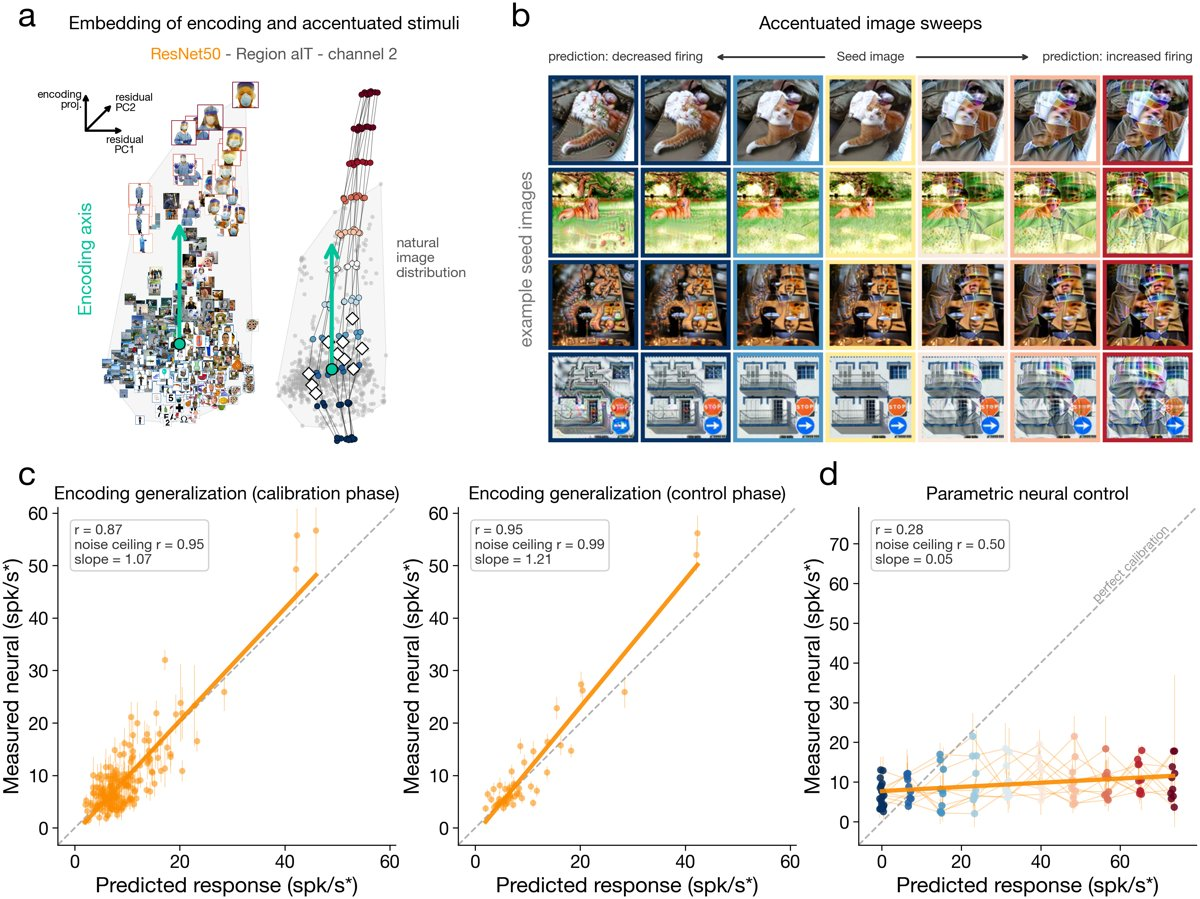

In [45]:
import io
from IPython.display import Image, display
from PIL import Image as PILImage

# A JPEG preview keeps the notebook small; open the PNG for full detail.
print(png)
im = PILImage.open(png).convert("RGB")
im.thumbnail((1200, 1200))
buf = io.BytesIO(); im.save(buf, "JPEG", quality=85, optimize=True)
display(Image(data=buf.getvalue(), format="jpeg", width=900))

**Figure 3. Strong natural image encoding does not imply accurate neural control.** Results are shown for an example aIT site using the ResNet50 encoding model. (A) Visualization of site tuning in the best-fitting DNN layer feature space. Natural images are plotted in the same three-dimensional principal component space as in Fig. 2D and colored by recorded firing rate. The strongest natural-image responses were elicited by images of human faces, particularly photographic portraits of lab members wearing personal protective equipment. The adjacent plot shows the 10 accentuated image sweeps projected into the same space, extending beyond the natural-image distribution along the encoding axis. (B) Example accentuated image sweeps for four seed images. Border colors indicate predicted response levels from low to high firing. (C) Encoding accuracy over natural images across phases. Scatter plots show predicted versus true neural firing rates for phase-1 validation images and phase-2 re-presented held-out images (the cross-session re-test set; see Methods). Dashed gray lines indicate identity, and orange lines indicate linear fits. (D) Parametric neural control over axis-aligned accentuated stimuli. Colored traces indicate seed image sweeps, and dots indicate individual accentuated images with vertical error bars indicating the SEM response over repeats.